In [9]:
import scipy.io as sio
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import stft
%matplotlib inline

In [10]:
import os

os.chdir("../")

In [11]:
%pwd

'c:\\Users\\Rounak\\Desktop\\OneDrive\\College\\Projects\\Privacy-Preserving-Human-Pose-Estimation-from-WiFi'

In [12]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class DataTransformationConfig:
    root_dir: Path
    data_dir: Path

In [13]:
from PrivacyPreservingHumanPoseEstimationFromWiFi.utils.common import read_yaml, create_directories
from PrivacyPreservingHumanPoseEstimationFromWiFi.constants import *

In [14]:
class ConfigurationManager:
    def __init__(self, config_filepath = CONFIG_FILE_PATH, params_filepath = PARAMS_FILE_PATH):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        create_directories([self.config.artifacts_root])

    def get_data_transformation_config(self) -> DataTransformationConfig:
        config = self.config.data_transformation
        create_directories([config.root_dir])

        data_transformation_config = DataTransformationConfig(
            root_dir = config.root_dir,
            data_dir = config.data_dir,
        )
        return data_transformation_config

In [15]:
class DataTransformation:
    def __init__(self, config: DataTransformationConfig):
        self.config = config
        self.filename = []
        self.csi = None
    
    def get_csi_files(self):
        for filename in os.listdir(self.config.data_dir):
            if filename.endswith(".mat"):
                self.filename.append(filename)
        print(self.filename)

    def load_csi_data(self):
        self.get_csi_files()
        mat = sio.loadmat(self.config.data_dir+"/"+self.filename[-1])
        self.csi = mat['csi_buff']
        return self.csi


In [16]:
try:
    config = ConfigurationManager()
    data_transformation_config = config.get_data_transformation_config()
    data_transformation = DataTransformation(config = data_transformation_config)
    data = data_transformation.load_csi_data()

except Exception as e:
    raise e

[2023-10-10 20:27:25,599: INFO: common] Successfully read yaml file from config\config.yaml
[2023-10-10 20:27:25,602: INFO: common] Successfully read yaml file from params.yaml
[2023-10-10 20:27:25,604: INFO: common] Created directory at: artifacts
[2023-10-10 20:27:25,606: INFO: common] Created directory at: artifacts/data_transformation
['AR1a_C.mat', 'AR1a_E.mat', 'AR1a_H.mat', 'AR1a_J1.mat', 'AR1a_J2.mat', 'AR1a_L.mat', 'AR1a_R.mat', 'AR1a_S.mat', 'AR1a_W.mat']


In [17]:
data.shape

(83708, 256)

In [20]:
import numpy as np
import pywt

# Assuming csi_data is your complex CSI data of shape (83708, 256)
csi_data = data
amplitude = np.abs(csi_data)
phase = np.angle(csi_data)

# Apply a linear transformation to phase values (e.g., mapping to [0, 2*pi])
phase = (phase + 2 * np.pi) % (2 * np.pi)

from scipy.signal import medfilt
# from scipy.stats import median_absolute_deviation

def hampel_filter(input_series, window_size, n_sigmas):
    median = np.median(input_series)
    mad = np.median(np.abs(input_series - median))
    is_outlier = np.abs(input_series - median) > (n_sigmas * mad)
    input_series[is_outlier] = median  # Replace outliers with the median
    return input_series

# Usage example
window_size = 5  # Adjust window size as needed
n_sigmas = 3  # Adjust the threshold as needed
filtered_phase = hampel_filter(phase, window_size, n_sigmas)
filtered_amplitude = hampel_filter(amplitude, window_size, n_sigmas)

def denoise_signal(signal, wavelet='db4', level=3):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    threshold = 0.3 * np.max(coeffs[0])  # Adjust threshold as needed
    denoised_coeffs = [pywt.threshold(c, threshold) for c in coeffs]
    denoised_signal = pywt.waverec(denoised_coeffs, wavelet)
    return denoised_signal

# Apply DWT noise reduction to amplitude and phase
denoised_amplitude = denoise_signal(filtered_amplitude)
denoised_phase = denoise_signal(filtered_phase)

# Now, denoised_amplitude and denoised_phase contain the preprocessed data



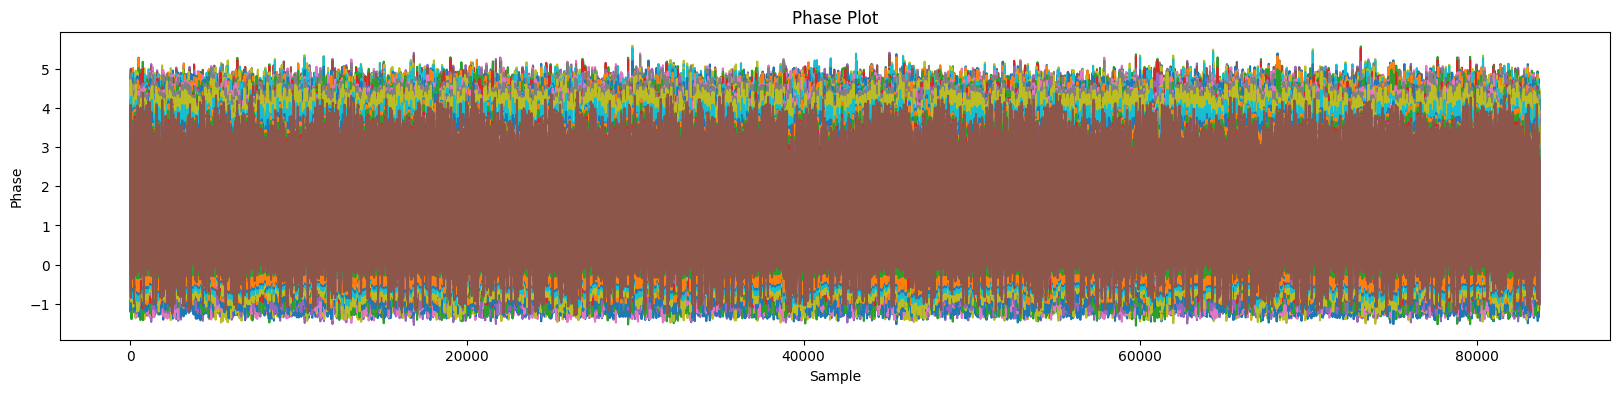

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 4))
plt.plot(denoised_phase)
plt.title('Phase Plot')
plt.xlabel('Sample')
plt.ylabel('Phase')
plt.show()


In [22]:
import matplotlib.pyplot as plt

# Original phase data
original_phase = np.angle(csi_data)  # Assuming you have your original phase data

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(20, 4))

# Plot original phase on the left subplot
axs[0].plot(original_phase)
axs[0].set_title('Original Phase')
axs[0].set_xlabel('Sample')
axs[0].set_ylabel('Phase')

# Plot preprocessed phase on the right subplot
axs[1].plot(denoised_phase)  # denoised_phase is the processed phase data
axs[1].set_title('Processed Phase')
axs[1].set_xlabel('Sample')
axs[1].set_ylabel('Phase')

plt.tight_layout()  # Ensures subplots don't overlap
plt.show()


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x000002163986CC10> (for post_execute):


KeyboardInterrupt: 